# **Projeto de IA em Saúde: Modelo Preditivo para Risco de Diabetes na População Pima**

> **Onde encontrar cada requisito do enunciado**
>
> | Requisito | Seção deste notebook |
> | :--- | :--- |
> | 1. Descrição do cenário | **1** |
> | 2. Tecnologias adotadas e justificativa | **2** |
> | 3. Descrição do dataset | **3** |
> | 4.1 Abertura dos dados | **3.1** |
> | 4.2 Pré-processamento | **4.2** |
> | 4.3 Análise exploratória (≥3 visualizações + insights) | **4.3** e **4.4** |
> | 4.4 Treinamento do modelo | **4.5** |
> | 4.5 Predição e explicabilidade | **4.7** |
> | 4.6 Avaliação do modelo | **4.6** |
> | 4.7 Conclusão | **5** |

---

# 1. Descrição do cenário

## 1.1 O problema

A diabetes é uma doença crônica que afeta milhões de pessoas em todo o mundo e representa um desafio significativo para os sistemas de saúde. A detecção precoce e a identificação de indivíduos em alto risco são cruciais para a prevenção e o manejo eficaz da doença, permitindo intervenções no estilo de vida (dieta, exercícios) que podem retardar ou até mesmo prevenir seu aparecimento.

Este projeto utiliza o dataset "Pima Indians Diabetes Database", originalmente coletado pelo Instituto Nacional de Diabetes e Doenças Digestivas e Renais dos EUA. O conjunto contém dados de saúde de mulheres com pelo menos 21 anos de idade, descendentes da tribo Pima, uma população com alta prevalência de diabetes. O objetivo é construir um modelo capaz de prever a probabilidade de uma paciente ter diabetes a partir de 8 medições diagnósticas.

## 1.2 Objetivo do projeto

O objetivo principal é **desenvolver e avaliar um modelo de Machine Learning para prever a presença de diabetes a partir de dados clínicos e demográficos.**

Os objetivos específicos são:

1.  **Análise Exploratória de Dados (AED):** entender a distribuição de cada variável e a correlação entre elas e o desfecho.
2.  **Pré-processamento e limpeza:** identificar os valores implausíveis (zeros inadequados) e convertê-los em `NaN`; construir dois datasets alternativos a partir de estratégias diferentes de tratamento dos ausentes; remover outliers do conjunto de treino; e padronizar os dados dentro de um `Pipeline`.
3.  **Visualização de dados:** comunicar os achados com mapas de calor, histogramas, box plots, matriz de confusão e curva ROC.
4.  **Treinamento e comparação de modelos:** comparar cinco algoritmos de classificação sob as mesmas condições.
5.  **Avaliação de performance:** usar acurácia, precisão, recall, F1-Score e AUC, além de validação cruzada estratificada.
6.  **Interpretabilidade:** identificar quais dos fatores de risco são determinantes para o diagnóstico, segundo o melhor modelo.

## 1.3 Contexto da organização

O projeto é desenvolvido no contexto de uma **Clínica de Atenção Primária à Saúde (fictícia)**, focada em medicina preventiva e manejo de doenças crônicas.

*   **Missão:** oferecer cuidados de saúde proativos e personalizados à comunidade, com forte foco na prevenção de doenças crônicas como diabetes, hipertensão e doenças cardíacas.
*   **Objetivo estratégico:** adotar ferramentas de análise de dados para criar "scores de risco" para os pacientes. Este projeto é uma prova de conceito de como um modelo de Machine Learning, treinado com dados clínicos de rotina, pode automatizar e escalar a identificação de pacientes de alto risco.
*   **Aplicação prática:** se bem-sucedido, o modelo seria integrado ao prontuário eletrônico. Periodicamente, o sistema rodaria sobre a base de pacientes e geraria uma lista priorizada para a equipe de enfermagem. As pacientes de alto risco seriam contatadas para consulta de acompanhamento, exames adicionais e aconselhamento sobre estilo de vida.

## 1.4 Motivação: que problema o projeto resolve?

O processo atual da clínica é **reativo**: as pacientes de risco só são identificadas quando procuram atendimento por conta própria. Isso gera três problemas concretos:

1.  **Diagnóstico tardio.** A diabetes tipo 2 é assintomática por anos. Quando a paciente procura a clínica por sintomas, a doença frequentemente já causou dano vascular, renal ou retiniano irreversível.
2.  **Priorização sem critério objetivo.** Com uma base de pacientes maior do que a capacidade de acompanhamento ativo, a equipe precisa escolher quem chamar primeiro — hoje, sem um critério mensurável.
3.  **Desperdício da informação já coletada.** Os exames de rotina que alimentariam um score de risco **já existem** no prontuário. Falta apenas transformá-los em uma priorização.

O projeto ataca os três: converte dados que a clínica já possui em uma lista ordenada de risco, permitindo agir **antes** do aparecimento dos sintomas.

# 2. Tecnologias adotadas

## 2.1 Abordagem de desenvolvimento

A abordagem é de **aprendizado supervisionado para classificação binária**, sobre dados tabulares estruturados. O fluxo segue o padrão de um projeto de ciência de dados: abertura → limpeza → análise exploratória → divisão treino/teste → treinamento → avaliação → interpretabilidade.

Todo o pré-processamento que "aprende" algo com os dados (a padronização) é encapsulado em um `Pipeline` do scikit-learn, de modo que ele seja reajustado a cada divisão — inclusive dentro da validação cruzada. É isso que impede o **vazamento de dados** (*data leakage*), o erro mais comum e mais difícil de perceber neste tipo de projeto.

Em vez de escolher uma única estratégia de tratamento dos valores ausentes, o projeto constrói **dois datasets alternativos** e os compara experimentalmente. A pergunta central é: *vale mais ter mais pacientes ou mais exames por paciente?*

## 2.2 Técnicas de Machine Learning utilizadas

Cinco algoritmos são comparados sob as mesmas condições, agrupados em três famílias:

### Modelos simples e interpretáveis

**Regressão Logística** — ponto de partida padrão para classificação. É rápida, eficiente e, sobretudo, **altamente interpretável**: o coeficiente atribuído a cada variável mostra a direção e a intensidade do seu efeito. Ponto fraco: assume relação linear entre as variáveis e a probabilidade do desfecho. Foi incluída como *baseline* e como candidata a modelo final justamente pela interpretabilidade, que é requisito prático em saúde.

**K-Nearest Neighbors (KNN)** — classifica uma paciente pela classe majoritária entre as suas vizinhas mais próximas. Útil quando pacientes de perfil semelhante tendem ao mesmo desfecho, sem relação linear. Ponto fraco: muito sensível à escala das variáveis, o que torna a padronização obrigatória.

### Modelos de ensemble

**Random Forest** — constrói centenas de árvores de decisão sobre subconjuntos aleatórios dos dados e das variáveis, e decide por votação. É robusto a outliers e não exige padronização. Ponto fraco: menos interpretável que a Regressão Logística — mostra a importância geral de cada variável, mas não a direção do efeito.

**XGBoost** — constrói árvores de forma sequencial, cada uma corrigindo os erros da anterior. É a referência de desempenho em dados tabulares. Ponto fraco: é o mais "caixa-preta" do conjunto e tem muitos hiperparâmetros.

> **Por que XGBoost e não LightGBM ou CatBoost?** As três bibliotecas implementam *gradient boosting* com desempenho comparável nesta escala de dados. O XGBoost foi escolhido por ser o mais maduro, o mais documentado e por já estar disponível no ambiente — com 392 a 724 amostras, a diferença de velocidade que justificaria o LightGBM é irrelevante.

### Outros modelos

**SVM (Support Vector Machines)** — busca o hiperplano que melhor separa as duas classes, com a maior margem possível, e lida com fronteiras não lineares através do *truque do kernel*. Ponto fraco: exige padronização, é caro computacionalmente e sua interpretação não é direta.

> **Hipótese inicial:** espera-se que os modelos de ensemble superem os simples, já que costumam liderar em dados tabulares. Essa hipótese é confrontada com os resultados na seção 5.

## 2.3 E as técnicas de PLN?

O enunciado admite projetos baseados em **Machine Learning *ou* em Processamento de Linguagem Natural**. Este projeto usa exclusivamente ML, e **nenhuma técnica de PLN é aplicada**.

A justificativa é o formato dos dados: o dataset é inteiramente **tabular e estruturado** — oito medições numéricas por paciente, sem nenhum campo de texto livre. PLN se aplicaria a fontes como evoluções clínicas, laudos de exames ou sumários de alta, que não existem aqui. Aplicar PLN a este conjunto seria forçar uma técnica ao problema errado.

## 2.4 Bibliotecas, pacotes e frameworks

| Biblioteca | Para que é usada aqui | Por que foi escolhida |
| :--- | :--- | :--- |
| **pandas** | Leitura do CSV, conversão dos zeros em `NaN`, criação dos dois DataFrames de trabalho | Padrão de fato para dados tabulares em Python; opera sobre dados rotulados, o que evita erros de índice ao filtrar linhas |
| **numpy** | Representação de valores ausentes (`np.nan`) e operações numéricas | Base numérica sobre a qual o pandas e o scikit-learn são construídos |
| **matplotlib** | Camada base de todos os gráficos | Controle fino de eixos, títulos e grades de subplots |
| **seaborn** | Box plots, histogramas e mapa de calor | Integra-se diretamente com DataFrames e produz gráficos estatísticos com muito menos código que o matplotlib puro |
| **scikit-learn** | Divisão treino/teste, padronização, `Pipeline`, quatro dos cinco modelos, métricas, validação cruzada e *permutation importance* | Oferece uma API única (`fit`/`predict`) para todos os modelos, o que torna a comparação justa; o `Pipeline` é o que garante a ausência de vazamento de dados |
| **xgboost** | Modelo de *gradient boosting* | Referência de desempenho em dados tabulares; entra na comparação como candidato de maior capacidade |

Optou-se por **não usar bibliotecas de deep learning**: com 768 registros e 8 variáveis, modelos clássicos são mais adequados, mais rápidos de treinar e — crucialmente para saúde — mais fáceis de interpretar.

In [1]:
# --- Manipulação de dados ---
import pandas as pd      # DataFrames: leitura do CSV, limpeza e agregações
import numpy as np       # operações numéricas e representação de NaN

# --- Visualização ---
import matplotlib.pyplot as plt   # base de todos os gráficos
import seaborn as sns             # gráficos estatísticos sobre o matplotlib
%matplotlib inline

# --- Pré-processamento e validação ---
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# --- Modelos de classificação ---
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# --- Métricas e avaliação ---
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, RocCurveDisplay,
                             confusion_matrix, ConfusionMatrixDisplay)

# --- Interpretabilidade ---
from sklearn.inspection import permutation_importance

# OBSERVAÇÃO: o ydata_profiling não é usado neste projeto. A biblioteca exige uma
# versão antiga do matplotlib e sua instalação quebra o ambiente; além disso, toda a
# análise exploratória é calculada aqui mesmo, o que a torna verificável célula a
# célula. A justificativa completa está na seção 4.3.

# 3. Descrição do dataset

## 3.1 Origem e abertura dos dados

O conjunto **Pima Indians Diabetes Database** foi obtido no **Kaggle**, e é originalmente do *National Institute of Diabetes and Digestive and Kidney Diseases* (NIDDK), dos Estados Unidos. O arquivo `diabetes.csv` está na mesma pasta deste notebook.

A célula a seguir carrega o CSV em um DataFrame do pandas e verifica se a leitura ocorreu corretamente — esta é a etapa de **abertura dos dados** (requisito 4.1 do enunciado).

In [2]:
file_path = 'diabetes.csv'

#  Carregar o arquivo CSV em um DataFrame pandas
try:
    df = pd.read_csv(file_path)

    # Passo 4: Verificar se os dados foram carregados corretamente
    print(f"Dataset '{file_path}' carregado com sucesso!")
    print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")
    
    print("\n--- 5 Primeiras Linhas do Dataset ---")
    # A função display() do Jupyter formata a tabela de forma mais elegante
    display(df.head())

    print("\n--- Informações Gerais do Dataset ---")
    df.info()

    print("\n--- Estatísticas Descritivas ---")
    display(df.describe())

except FileNotFoundError:
    print(f"Erro: O arquivo '{file_path}' não foi encontrado.")
    print("Por favor, verifique se o nome do arquivo está correto e se ele está na mesma pasta do seu notebook.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")


Dataset 'diabetes.csv' carregado com sucesso!
O dataset possui 768 linhas e 9 colunas.

--- 5 Primeiras Linhas do Dataset ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



--- Informações Gerais do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

--- Estatísticas Descritivas ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3.2 O que consta no dataset
Este conjunto de dados é originalmente do Instituto Nacional de Diabetes e Doenças Digestivas e Renais. O objetivo do conjunto de dados é prever, por meio de diagnóstico, se um paciente tem ou não diabetes, com base em certas medidas diagnósticas incluídas no conjunto de dados. Diversas restrições foram impostas à seleção desses casos a partir de um banco de dados maior. Em particular, todos os pacientes aqui são mulheres com pelo menos 21 anos de idade e de ascendência indígena Pima.

## 3.3 Dados utilizados no projeto
O conjunto de dados consiste em diversas variáveis preditoras médicas e uma variável alvo (**Outcome**). As variáveis preditoras incluem o número de gestações que a paciente teve, seu IMC, nível de insulina, idade, entre outras.


#### Variáveis Preditivas 

Estas são as 8 variáveis que usaremos para tentar prever o resultado.

1.  **`Pregnancies` (Número de Gestações)**
    *   **Significado:** O número de vezes que a paciente esteve grávida.
    *   **Contexto Clínico:** A gravidez pode induzir um estado de resistência à insulina, e múltiplas gestações são por vezes associadas a um risco aumentado de desenvolver diabetes tipo 2 mais tarde na vida. É um fator demográfico e de histórico de saúde importante.
    *   **Tipo:** Numérica, discreta.

2.  **`Glucose` (Glicose)**
    *   **Significado:** A concentração de glicose no plasma sanguíneo, medida 2 horas após a ingestão de uma quantidade padrão de açúcar (75g) durante um Teste Oral de Tolerância à Glicose (TOTG).
    *   **Contexto Clínico:** Esta é **uma das variáveis mais importantes**. Níveis elevados de glicose após o teste são um indicador chave de pré-diabetes ou diabetes. Um valor normal geralmente fica abaixo de 140 mg/dL, enquanto valores acima de 200 mg/dL indicam diabetes.
    *   **Tipo:** Numérica, contínua.

3.  **`BloodPressure` (Pressão Arterial)**
    *   **Significado:** Pressão arterial diastólica, medida em milímetros de mercúrio (mm Hg). A diastólica é a pressão nas artérias quando o coração está em repouso, entre os batimentos.
    *   **Contexto Clínico:** A hipertensão (pressão alta) é frequentemente associada à diabetes e faz parte da chamada "síndrome metabólica". Pacientes com diabetes têm um risco maior de desenvolver pressão alta, e vice-versa.
    *   **Tipo:** Numérica, contínua.

4.  **`SkinThickness` (Espessura da Dobra Cutânea)**
    *   **Significado:** A espessura da dobra da pele do tríceps, medida em milímetros (mm).
    *   **Contexto Clínico:** É uma medida usada para estimar a gordura corporal. Níveis mais altos de gordura corporal estão fortemente correlacionados com a resistência à insulina e o risco de diabetes tipo 2.
    *   **Tipo:** Numérica, contínua.

5.  **`Insulin` (Insulina)**
    *   **Significado:** O nível de insulina no soro sanguíneo, medido 2 horas após o início do teste de tolerância à glicose, em micro unidades por mililitro (mu U/ml).
    *   **Contexto Clínico:** Esta é outra **variável crucial**. No início da resistência à insulina (pré-diabetes), o pâncreas tenta compensar produzindo *mais* insulina. Portanto, níveis elevados de insulina podem indicar que o corpo está lutando para controlar o açúcar no sangue. Em estágios avançados da diabetes tipo 2, a produção de insulina pode diminuir.
    *   **Tipo:** Numérica, contínua.

6.  **`BMI` (Body Mass Index / Índice de Massa Corporal)**
    *   **Significado:** Um índice calculado a partir do peso e da altura de uma pessoa (peso em kg / (altura em m)²).
    *   **Contexto Clínico:** O IMC é uma medida amplamente utilizada para classificar o peso de uma pessoa (abaixo do peso, normal, sobrepeso, obesidade). A obesidade (IMC > 30) é um dos maiores fatores de risco para o desenvolvimento de diabetes tipo 2.
    *   **Tipo:** Numérica, contínua.

7.  **`DiabetesPedigreeFunction` (Função de Predisposição Genética para Diabetes)**
    *   **Significado:** Uma função que calcula uma pontuação de risco de diabetes com base no histórico familiar da paciente (idade e diagnóstico de diabetes em parentes).
    *   **Contexto Clínico:** Esta variável sintetiza a predisposição genética. Um valor mais alto indica uma maior probabilidade de ter a doença com base na genética familiar, que é um fator de risco bem conhecido.
    *   **Tipo:** Numérica, contínua.

8.  **`Age` (Idade)**
    *   **Significado:** A idade da paciente em anos.
    *   **Contexto Clínico:** O risco de desenvolver diabetes tipo 2 aumenta significativamente com a idade, especialmente após os 45 anos.
    *   **Tipo:** Numérica, discreta.

#### Variável Alvo (Target)

Esta é a variável que queremos que o nosso modelo aprenda a prever.

9.  **`Outcome` (Desfecho / Resultado)**
    *   **Significado:** Uma variável binária que indica se a paciente foi diagnosticada com diabetes ou não.
    *   **Valores:**
        *   **1**: A paciente tem diabetes.
        *   **0**: A paciente não tem diabetes.
    *   **Tipo:** Categórica, binária.

---

## 3.4 Em quais tarefas este dataset poderia ser útil?

Além da classificação binária que é o objeto deste projeto, o conjunto de dados se presta a:

* **Estratificação de risco:** em vez da resposta "tem/não tem", usar a *probabilidade* prevista para ordenar pacientes por prioridade de acompanhamento — que é exatamente o "score de risco" descrito no cenário da clínica.
* **Estudo de dados ausentes:** com 48,7% de `Insulin` e 29,6% de `SkinThickness` faltando, é um caso didático para comparar técnicas de imputação (mediana, KNN, imputação preditiva) e medir o impacto de cada uma.
* **Análise de subgrupos:** investigar se o modelo tem desempenho diferente por faixa etária ou número de gestações — uma verificação de equidade obrigatória em aplicações clínicas.
* **Regressão:** prever um valor contínuo, como o nível de glicose, a partir das demais variáveis.
* **Detecção de anomalias:** identificar registros clinicamente implausíveis, como os zeros tratados na próxima seção.


# 4. Programa funcional

## 4.2 Pré-processamento e limpeza
Um desafio interessante neste dataset é que alguns valores "zero" em certas colunas (como `Glucose`, `BloodPressure` ou `BMI`) são, na verdade, dados ausentes ou implausíveis (uma pessoa não pode ter pressão arterial de 0). Tratar esses valores de forma adequada será uma parte importante do pré-processamento.

### Tratando os valores zero
Vamos substituir os valores zeros por NaN. 

In [3]:
# Identificar e contar os zeros nas colunas onde zero é um valor inválido.
# Não incluímos 'Pregnancies' e 'Outcome', pois 0 é um valor válido para elas.
colunas_com_zeros_invalidos = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


print("--- Contagem de Zeros Inválidos Antes da Substituição ---")
# Itera sobre a lista de colunas e conta quantos zeros existem em cada uma.
for coluna in colunas_com_zeros_invalidos:
    num_zeros = (df[coluna] == 0).sum()
    print(f"Coluna '{coluna}': {num_zeros} zeros")

#  Substituir os zeros por NaN (Not a Number) diretamente no DataFrame 'df'.
df[colunas_com_zeros_invalidos] = df[colunas_com_zeros_invalidos].replace(0, np.nan)
print("\nValores '0' substituídos por NaN no DataFrame 'df'.")

#  Confirmar a contagem de valores nulos de forma explícita.
print("\n--- Contagem de Valores Nulos (NaN) por Coluna ---")
print(df.isnull().sum())

print("Porcentagem de valores ausentes por coluna:")
((df.isnull().sum() / df.shape[0])*100).sort_values(ascending=False)

--- Contagem de Zeros Inválidos Antes da Substituição ---
Coluna 'Glucose': 5 zeros
Coluna 'BloodPressure': 35 zeros
Coluna 'SkinThickness': 227 zeros
Coluna 'Insulin': 374 zeros
Coluna 'BMI': 11 zeros
Coluna 'DiabetesPedigreeFunction': 0 zeros
Coluna 'Age': 0 zeros

Valores '0' substituídos por NaN no DataFrame 'df'.

--- Contagem de Valores Nulos (NaN) por Coluna ---
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Porcentagem de valores ausentes por coluna:


Insulin                     48.697917
SkinThickness               29.557292
BloodPressure                4.557292
BMI                          1.432292
Glucose                      0.651042
Pregnancies                  0.000000
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                      0.000000
dtype: float64

### Análise das Porcentagens de Valores Ausentes

*   **`Insulin`: 48,7%**
    *   **Problema:** quase metade dos dados de insulina está faltando. É uma quantidade muito significativa.
    *   **Impacto:** remover quase metade das linhas do dataset seria custoso, pois perderíamos informação valiosa das outras colunas. Preencher quase 50% dos valores com uma única estatística (média/mediana) também é arriscado: distorce a distribuição natural da variável e diminui seu poder preditivo.

*   **`SkinThickness`: 29,6%**
    *   **Problema:** similar à insulina, mas menos severo. Quase um terço dos dados está ausente.
    *   **Impacto:** as mesmas preocupações se aplicam. A imputação precisa ser feita com cuidado.

*   **`BloodPressure`: 4,6%**, **`BMI`: 1,4%**, **`Glucose`: 0,7%**
    *   **Problema:** quantidade pequena e gerenciável de ausentes.
    *   **Impacto:** aqui a remoção das linhas afetadas é segura, pois custa pouquíssimos registros.

### Estratégia de Pré-processamento (Plano de Ação)

Em vez de escolher uma única estratégia no escuro, vamos **construir dois datasets e compará-los experimentalmente**:

| | `df_limpo` | `df_short` |
| :--- | :--- | :--- |
| **Linhas** | mais (~724) | menos (~392) |
| **Colunas** | 6 preditoras | 8 preditoras |
| **Como é construído** | remove as linhas com ausentes em `Glucose`, `BloodPressure` e `BMI`, e **descarta as colunas** `Insulin` e `SkinThickness` | remove **todas** as linhas com qualquer ausente, mantendo todas as colunas |
| **Aposta** | mais dados para treinar, menos informação por paciente | menos dados, porém completos e mais ricos |

Essa é a pergunta central do projeto: **vale mais ter mais pacientes ou mais exames por paciente?** Ao final, os mesmos cinco modelos serão treinados nos dois conjuntos e comparados sob as mesmas métricas.

> **Nota metodológica:** a opção de imputação preditiva (KNN, regressão) foi descartada por complexidade e pelo risco de vazamento de dados se aplicada fora de um `Pipeline`. Fica registrada como próximo passo na conclusão.

#### Passos 1 e 2
Criaremos um novo dataframe  após realizar os passos 1 e 2.

In [4]:
# ---  Criar uma cópia do DataFrame para não alterar o original ---
# Todas as operações de limpeza serão feitas no 'df_limpo'.
df_limpo = df.copy()

print("--- Estado Inicial dos DataFrames ---")
print(f"df_limpo (cópia) possui {df_limpo.shape[0]} linhas e {df_limpo.shape[1]} colunas.")
print("-" * 50)


# --- Excluir as LINHAS com valores ausentes em colunas específicas do df_limpo ---
# Definimos as colunas onde não aceitaremos valores ausentes.
colunas_para_limpar_linhas = ['Glucose', 'BloodPressure', 'BMI']

# Usamos .dropna() no df_limpo. O resultado é atribuído de volta a ele mesmo.
# O argumento 'subset' especifica que devemos olhar apenas para estas colunas.
df_limpo = df_limpo.dropna(subset=colunas_para_limpar_linhas)

print("\n--- Após exclusão de LINHAS no 'df_limpo' ---")
print(f"df_limpo agora possui {df_limpo.shape[0]} linhas.")
print("-" * 50)


# ---  Excluir as COLUNAS 'Insulin' e 'SkinThickness' do df_limpo ---
# Usamos .drop() para remover as colunas.
# 'axis=1' especifica que queremos remover COLUNAS.
colunas_para_excluir = ['Insulin', 'SkinThickness']
df_limpo = df_limpo.drop(columns=colunas_para_excluir)

print("\n--- Após exclusão de COLUNAS no 'df_limpo' ---")
print(f"df_limpo agora possui {df_limpo.shape[1]} colunas.")
print(f"Colunas restantes: {df_limpo.columns.tolist()}")
print("-" * 50)

df_limpo.info()

--- Estado Inicial dos DataFrames ---
df_limpo (cópia) possui 768 linhas e 9 colunas.
--------------------------------------------------

--- Após exclusão de LINHAS no 'df_limpo' ---
df_limpo agora possui 724 linhas.
--------------------------------------------------

--- Após exclusão de COLUNAS no 'df_limpo' ---
df_limpo agora possui 7 colunas.
Colunas restantes: ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 724 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               724 non-null    int64  
 1   Glucose                   724 non-null    float64
 2   BloodPressure             724 non-null    float64
 3   BMI                       724 non-null    float64
 4   DiabetesPedigreeFunction  724 non-null    float64

#### Passos 1 e 3
Criaremos um novo dataframe após realizar os passos 1 e 3.

In [5]:
# --- Criar uma cópia do DataFrame original ---
# O novo DataFrame 'df_short' receberá as modificações.
df_short = df.copy()

print("--- Estado Inicial dos DataFrames ---")
print(f"df_short (cópia) possui {df_short.shape[0]} linhas e {df_short.shape[1]} colunas.")
print("-" * 50)


# --- Excluir TODAS as linhas que contenham QUALQUER valor ausente (NaN) ---
# O método .dropna() sem argumentos remove qualquer linha que tenha pelo menos um NaN.
# O resultado da operação (um DataFrame menor) é atribuído de volta a 'df_short'.
df_short = df_short.dropna()

print("\n--- Após remover TODAS as linhas com valores NaN do 'df_short' ---")
print(f"O 'df_short' agora possui {df_short.shape[0]} linhas.")
print(f"Foram removidas {df.shape[0] - df_short.shape[0]} linhas.")
print("-" * 50)

print("\n--- Após exclusão de COLUNAS no 'df_short' ---")
print(f"df_short agora possui {df_short.shape[1]} colunas.")
print(f"Colunas restantes: {df_short.columns.tolist()}")
print("-" * 50)

df_short.info()

--- Estado Inicial dos DataFrames ---
df_short (cópia) possui 768 linhas e 9 colunas.
--------------------------------------------------

--- Após remover TODAS as linhas com valores NaN do 'df_short' ---
O 'df_short' agora possui 392 linhas.
Foram removidas 376 linhas.
--------------------------------------------------

--- Após exclusão de COLUNAS no 'df_short' ---
df_short agora possui 9 colunas.
Colunas restantes: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 3 to 765
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               392 non-null    int64  
 1   Glucose                   392 non-null    float64
 2   BloodPressure             392 non-null    float64
 3   SkinThickness          

## 4.3 Análise exploratória dos dados

### Abordagem da análise exploratória

Toda a análise exploratória deste projeto é calculada **dentro do notebook**, com `pandas` e `seaborn`. A escolha é deliberada: qualquer número citado no texto pode ser conferido na saída da célula que o produziu, sem depender de arquivos externos.

Uma alternativa comum é a biblioteca `ydata-profiling`, que gera automaticamente um relatório HTML com estatísticas, correlações e alertas sobre o dataset. É excelente para uma primeira varredura, mas foi descartada aqui por dois motivos:

1. **Verificabilidade.** Ler coeficientes em um mapa de calor exportado é impreciso, e o conteúdo do relatório vive fora do notebook entregue.
2. **Conflito de dependências.** A biblioteca exige uma versão antiga do `matplotlib`, e instalá-la quebra o ambiente usado por este notebook.

As próximas células cobrem o mesmo terreno de forma explícita e reproduzível: matriz de correlação, distribuição de cada variável por classe e detecção de outliers.

### Análise de correlação

A seguir a matriz de correlação de Pearson é **calculada no próprio notebook**, para que os valores citados no texto possam ser conferidos por quem lê. Um mapa de calor torna a leitura imediata: quanto mais intensa a cor, mais forte a relação.

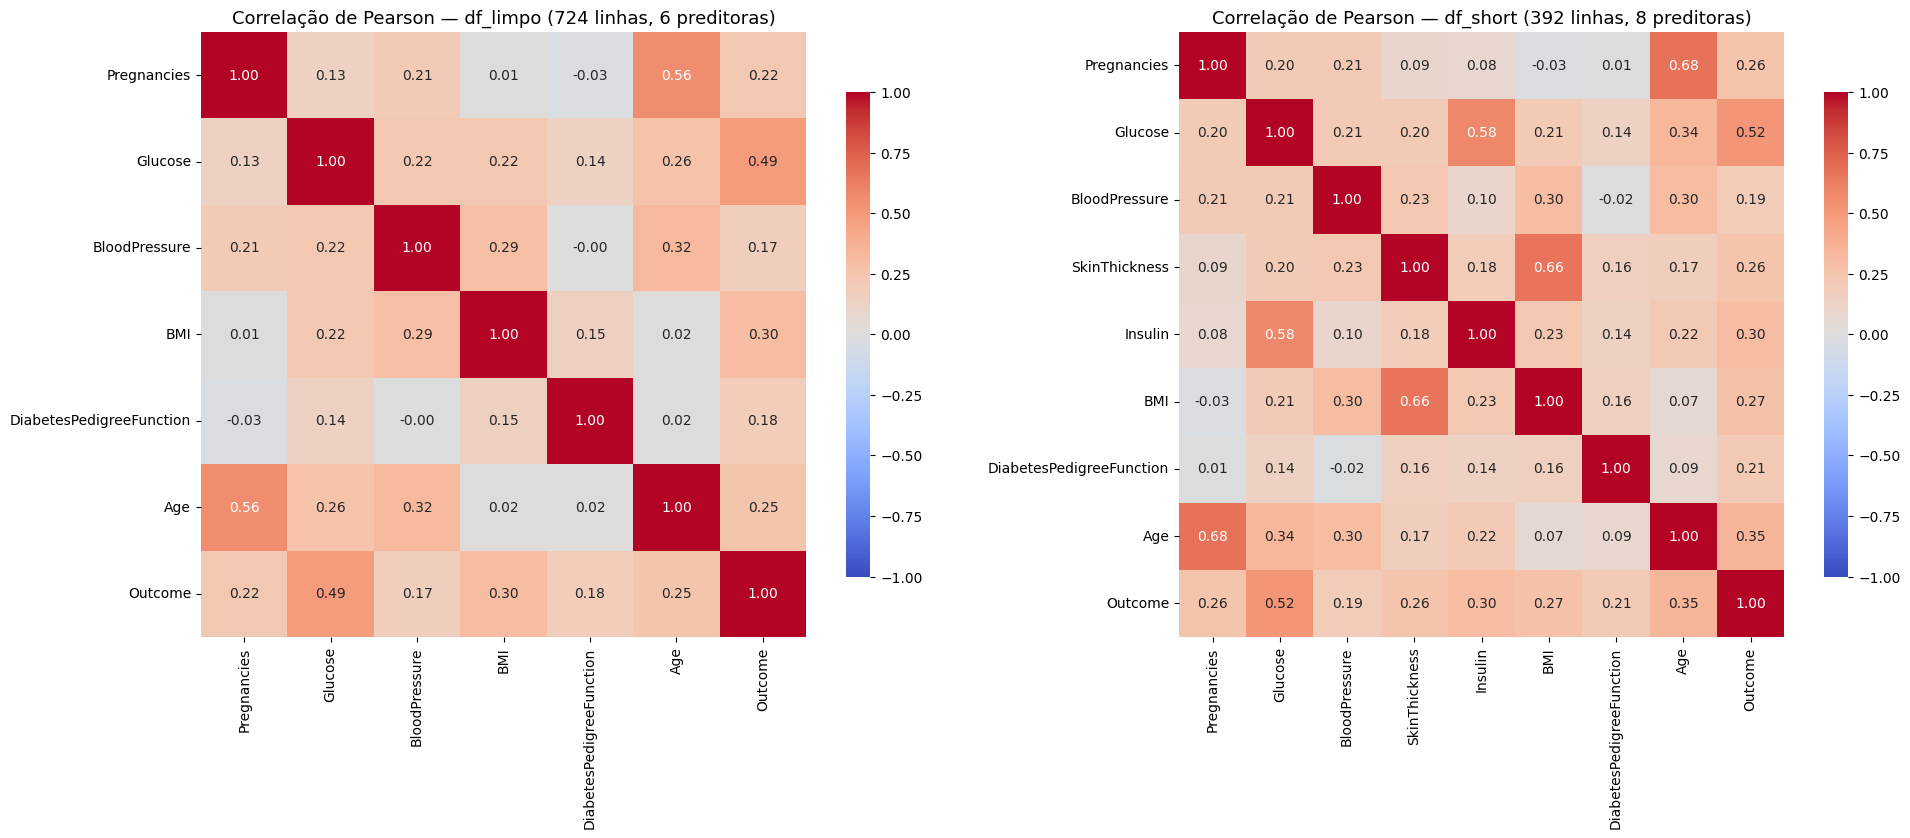

Correlação com 'Outcome', ordenada da mais forte para a mais fraca:

--- df_limpo ---
Glucose                     0.488
BMI                         0.299
Age                         0.246
Pregnancies                 0.224
DiabetesPedigreeFunction    0.185
BloodPressure               0.167

--- df_short ---
Glucose                     0.516
Age                         0.351
Insulin                     0.301
BMI                         0.270
Pregnancies                 0.257
SkinThickness               0.256
DiabetesPedigreeFunction    0.209
BloodPressure               0.193



In [6]:
# --- MATRIZ DE CORRELAÇÃO DOS DOIS DATAFRAMES (visualização 1 de 6: mapa de calor) ---

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, (nome, base) in zip(axes, [('df_limpo (724 linhas, 6 preditoras)', df_limpo),
                                   ('df_short (392 linhas, 8 preditoras)', df_short)]):
    # annot=True escreve o valor dentro de cada célula; fmt limita as casas decimais
    sns.heatmap(base.corr(), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, square=True, ax=ax,
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Correlação de Pearson — {nome}', fontsize=13)

plt.tight_layout()
plt.show()

# --- CORRELAÇÃO DE CADA VARIÁVEL COM O ALVO ---
print("Correlação com 'Outcome', ordenada da mais forte para a mais fraca:\n")
for nome, base in [('df_limpo', df_limpo), ('df_short', df_short)]:
    corr_alvo = base.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
    print(f"--- {nome} ---")
    print(corr_alvo.round(3).to_string())
    print()

### Leitura das correlações

**Preditor mais forte.** Em ambos os conjuntos a **`Glucose`** é, de longe, a variável mais associada ao diagnóstico — o que faz todo o sentido clínico, já que o teste de tolerância à glicose é o próprio exame diagnóstico da diabetes.

**Multicolinearidade.** No `df_short` aparecem dois pares de variáveis que carregam informação parecida:

* `BMI` ↔ `SkinThickness` — ambas medem gordura corporal;
* `Glucose` ↔ `Insulin` — fisiologicamente acopladas, já que o corpo libera insulina em resposta à glicose.

A tentação aqui é descartar uma variável de cada par. **Optamos por manter todas**, por três motivos:

1. A pergunta que o projeto se propõe a responder é justamente se `Insulin` e `SkinThickness` agregam valor — removê-las inviabilizaria o experimento e tornaria a comparação entre `df_limpo` e `df_short` uma comparação apenas de tamanho de amostra.
2. Multicolinearidade prejudica a *interpretação dos coeficientes* de modelos lineares, mas afeta pouco o **poder preditivo** — e praticamente nada em modelos de árvore como Random Forest e XGBoost.
3. Com apenas 8 variáveis, não há problema de dimensionalidade que justifique o descarte.

A etapa de interpretabilidade, ao final, mostrará quanto cada variável realmente contribuiu — uma forma mais confiável de avaliar redundância do que a correlação isolada.

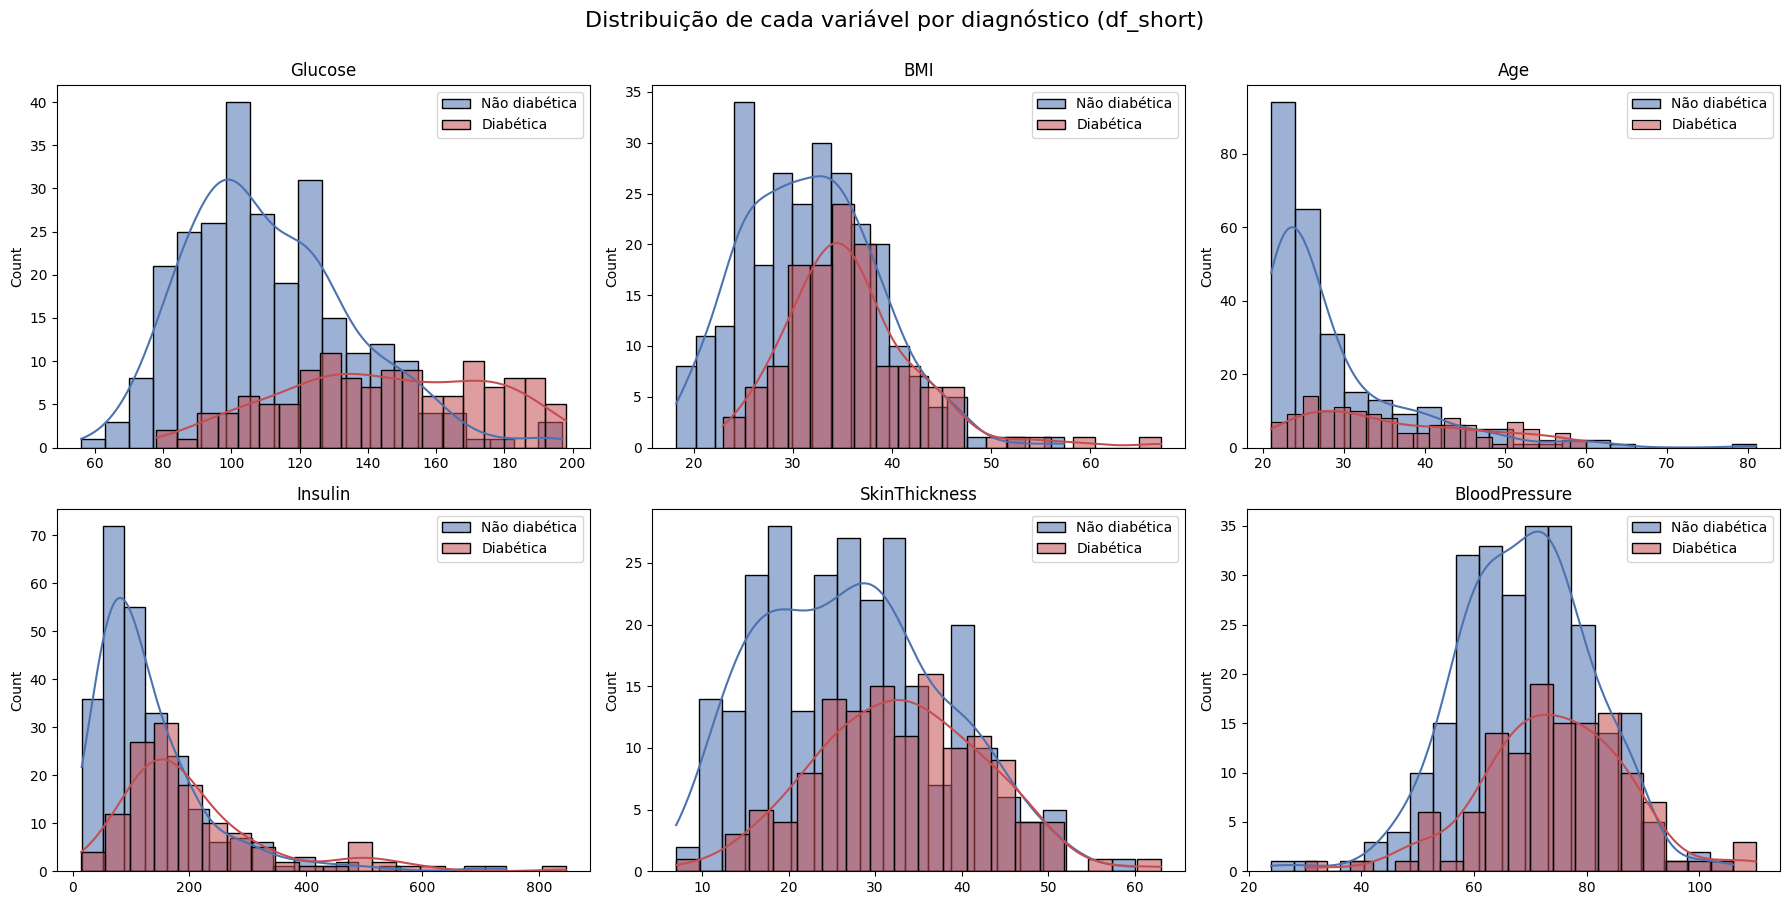

In [7]:
# --- DISTRIBUIÇÃO DAS VARIÁVEIS POR CLASSE (visualização 2 de 6: histogramas por classe) ---
# Enquanto o box plot resume a distribuição, o histograma mostra a FORMA dela.
# Separando por Outcome, vemos quais variáveis realmente separam os dois grupos.

variaveis = ['Glucose', 'BMI', 'Age', 'Insulin', 'SkinThickness', 'BloodPressure']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
plt.suptitle('Distribuição de cada variável por diagnóstico (df_short)', fontsize=16, y=1.00)

for ax, col in zip(axes.ravel(), variaveis):
    for valor, rotulo, cor in [(0, 'Não diabética', '#4C72B0'), (1, 'Diabética', '#C44E52')]:
        sns.histplot(df_short[df_short['Outcome'] == valor][col],
                     ax=ax, label=rotulo, color=cor, alpha=0.55, kde=True, bins=20)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    ax.legend()

plt.tight_layout()
plt.show()

#### Insights dos histogramas

* **`Glucose`** é a variável que mais separa os dois grupos: a distribuição das diabéticas está claramente deslocada para a direita, com pouca sobreposição na faixa acima de 140 mg/dL. Confirma visualmente o que a correlação já indicava.
* **`Age`** mostra que as não diabéticas se concentram fortemente abaixo dos 30 anos, enquanto as diabéticas se distribuem de forma mais espalhada pelas faixas mais velhas.
* **`Insulin`** tem forte assimetria à direita nos dois grupos, com uma cauda longa entre as diabéticas — coerente com a hiperinsulinemia compensatória da resistência à insulina.
* **`BloodPressure`** é a que menos separa: as duas distribuições quase se sobrepõem, o que explica sua baixa correlação com o alvo.
* **`BMI`** e **`SkinThickness`** mostram deslocamento moderado, com sobreposição considerável — informativas, mas não decisivas isoladamente.

## 4.4 Divisão do dataset e preparação
Agora vamos dividir o dataset em duas base de dados;
* Treinamento: 80% dos dados serão usados para treinar os modelos.
* Teste: 20% dos dados serão usados para testar os modelos.

### df_limpo
Vamos dividir o df_limpo em treino e teste:

In [8]:
# Divisão em treino (80%) e teste (20%)
# stratify=y garante que a proporção de diabéticas seja a mesma nos dois conjuntos.
# Sem isso, com poucas amostras, o teste pode ficar com um balanceamento bem diferente
# do treino — e a avaliação passa a medir o azar do sorteio, não o modelo.
X_train_limpo, X_test_limpo, y_train_limpo, y_test_limpo = train_test_split(
    df_limpo.drop(['Outcome'], axis=1),   # variáveis preditoras
    df_limpo['Outcome'],                  # coluna usada como label
    test_size=0.2,
    random_state=35,                      # "seed", para o split ser reproduzível
    stratify=df_limpo['Outcome']          # mantém a proporção das classes
)

print("Dimensões dos conjuntos (df_limpo):")
print("dataset completo:", df_limpo.shape)
print("X_train_limpo:", X_train_limpo.shape, "| y_train_limpo:", y_train_limpo.shape)
print("X_test_limpo: ", X_test_limpo.shape, " | y_test_limpo: ", y_test_limpo.shape)
print("-" * 40)
print("Proporção de diabéticas | completo: {:.1%} | treino: {:.1%} | teste: {:.1%}".format(
    df_limpo['Outcome'].mean(), y_train_limpo.mean(), y_test_limpo.mean()))

Dimensões dos conjuntos (df_limpo):
dataset completo: (724, 7)
X_train_limpo: (579, 6) | y_train_limpo: (579,)
X_test_limpo:  (145, 6)  | y_test_limpo:  (145,)
----------------------------------------
Proporção de diabéticas | completo: 34.4% | treino: 34.4% | teste: 34.5%


### df_short
Vamos dividir o df_short em treino e teste:

In [9]:
# Mesma divisão para o df_short, também estratificada
X_train_short, X_test_short, y_train_short, y_test_short = train_test_split(
    df_short.drop(['Outcome'], axis=1),
    df_short['Outcome'],
    test_size=0.2,
    random_state=35,
    stratify=df_short['Outcome']
)

print("Dimensões dos conjuntos (df_short):")
print("dataset completo:", df_short.shape)
print("X_train_short:", X_train_short.shape, "| y_train_short:", y_train_short.shape)
print("X_test_short: ", X_test_short.shape, " | y_test_short: ", y_test_short.shape)
print("-" * 40)
print("Proporção de diabéticas | completo: {:.1%} | treino: {:.1%} | teste: {:.1%}".format(
    df_short['Outcome'].mean(), y_train_short.mean(), y_test_short.mean()))

Dimensões dos conjuntos (df_short):
dataset completo: (392, 9)
X_train_short: (313, 8) | y_train_short: (313,)
X_test_short:  (79, 8)  | y_test_short:  (79,)
----------------------------------------
Proporção de diabéticas | completo: 33.2% | treino: 33.2% | teste: 32.9%


### Tratamento de outliers



Vamos usar Box Plot para verificar os **outliers**, **dispersão dos dados** e **simetria dos dados**:

### X_train_limpo

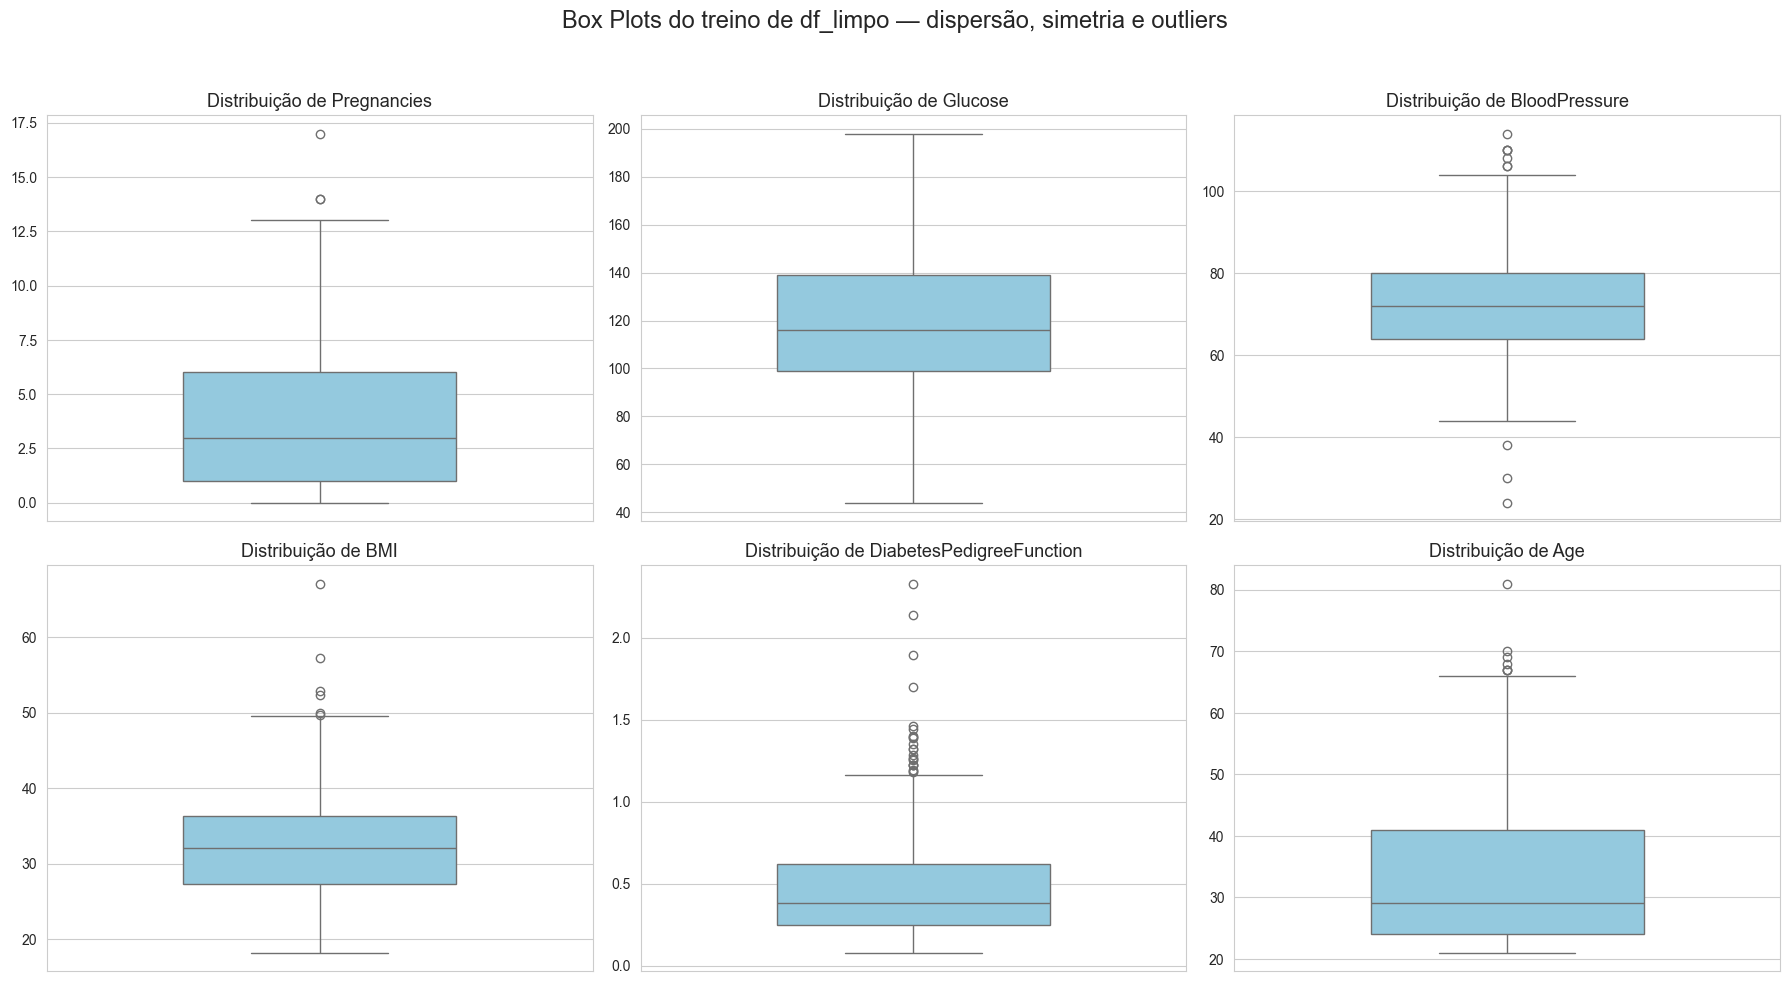

In [10]:
# --- BOX PLOTS (visualização 3 de 6) ---
numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']

sns.set_style("whitegrid")
plt.figure(figsize=(18, 10))
plt.suptitle("Box Plots do treino de df_limpo — dispersão, simetria e outliers", fontsize=17, y=0.98)

for i_col, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i_col + 1)
    sns.boxplot(y=X_train_limpo[col], color='skyblue', width=0.5)
    plt.title(f'Distribuição de {col}', fontsize=13)
    plt.ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Leitura dos box plots — `df_limpo`

Os gráficos mostram três coisas ao mesmo tempo: a **dispersão** (altura da caixa), a **simetria** (posição da mediana dentro da caixa) e os **outliers** (pontos além dos "bigodes").

* **`DiabetesPedigreeFunction` e `Age`** são as mais assimétricas: a mediana fica na parte baixa da caixa e há uma cauda longa para cima. São distribuições concentradas nos valores baixos, com poucas pacientes muito acima da média.
* **`Glucose` e `BloodPressure`** são as mais simétricas, com a mediana próxima do centro da caixa.
* **`Pregnancies`** tem caixa larga em relação à escala, indicando grande variabilidade entre as pacientes.
* Praticamente todas as variáveis apresentam outliers **na cauda superior**, e nenhuma na inferior.

Esse último ponto explica um detalhe dos limites calculados na célula seguinte: para `Pregnancies`, `DiabetesPedigreeFunction` e `Age`, o critério do IQR produz um **limite inferior negativo** — impossível para todas elas. Na prática, portanto, apenas a cauda superior é filtrada.

#### Removendo outliers — **apenas do conjunto de treino**

Os limites são calculados pelo critério do IQR usando **somente** `X_train_limpo`, e aplicados **somente** ao treino.

> **Por que o conjunto de teste não pode ser filtrado?** O teste existe para simular o que acontecerá em produção. Na clínica real, não é possível recusar-se a avaliar uma paciente por ela ter glicose alta ou idade acima da média — e são justamente essas as pacientes de maior risco. Descartá-las da avaliação removeria preferencialmente as diabéticas, inflando artificialmente as métricas e escondendo os erros que mais importam. Limpar o treino é uma decisão de modelagem; limpar o teste é enganar a si mesmo.

In [11]:
# --- LIMITES DE OUTLIER APRENDIDOS SOMENTE COM O TREINO ---
colunas_para_verificar = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI',
                          'DiabetesPedigreeFunction', 'Age']

print("--- Limites calculados a partir do conjunto de treino (critério IQR) ---")
limites = {}
for coluna in colunas_para_verificar:
    Q1 = X_train_limpo[coluna].quantile(0.25)
    Q3 = X_train_limpo[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limites[coluna] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    print(f"Coluna '{coluna}': [{limites[coluna][0]:.2f}, {limites[coluna][1]:.2f}]")

# --- APLICAR O FILTRO APENAS AO TREINO ---
X_train_limpo_outlier = X_train_limpo.copy()
y_train_limpo_outlier = y_train_limpo.copy()

for coluna in colunas_para_verificar:
    inf, sup = limites[coluna]
    mascara = (X_train_limpo_outlier[coluna] >= inf) & (X_train_limpo_outlier[coluna] <= sup)
    X_train_limpo_outlier = X_train_limpo_outlier[mascara]
    y_train_limpo_outlier = y_train_limpo_outlier[mascara]

print("\n--- Resultado ---")
print(f"Treino: {len(X_train_limpo)} -> {len(X_train_limpo_outlier)} "
      f"(removidos {len(X_train_limpo) - len(X_train_limpo_outlier)} outliers)")
print(f"Teste:  {len(X_test_limpo)} -> {len(X_test_limpo)} (INTACTO, de propósito)")
print(f"Proporção de diabéticas no treino após a limpeza: {y_train_limpo_outlier.mean():.1%}")

print("\n--- Amostra do treino limpo ---")
display(X_train_limpo_outlier.head())

--- Limites calculados a partir do conjunto de treino (critério IQR) ---
Coluna 'Pregnancies': [-6.50, 13.50]
Coluna 'Glucose': [39.00, 199.00]
Coluna 'BloodPressure': [40.00, 104.00]
Coluna 'BMI': [13.88, 49.67]
Coluna 'DiabetesPedigreeFunction': [-0.30, 1.17]
Coluna 'Age': [-1.50, 66.50]

--- Resultado ---
Treino: 579 -> 532 (removidos 47 outliers)
Teste:  145 -> 145 (INTACTO, de propósito)
Proporção de diabéticas no treino após a limpeza: 32.5%

--- Amostra do treino limpo ---


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
314,7,109.0,80.0,35.9,1.127,43
105,1,126.0,56.0,28.7,0.801,21
319,6,194.0,78.0,23.5,0.129,59
725,4,112.0,78.0,39.4,0.236,38
443,8,108.0,70.0,30.5,0.955,33


### X_train_short

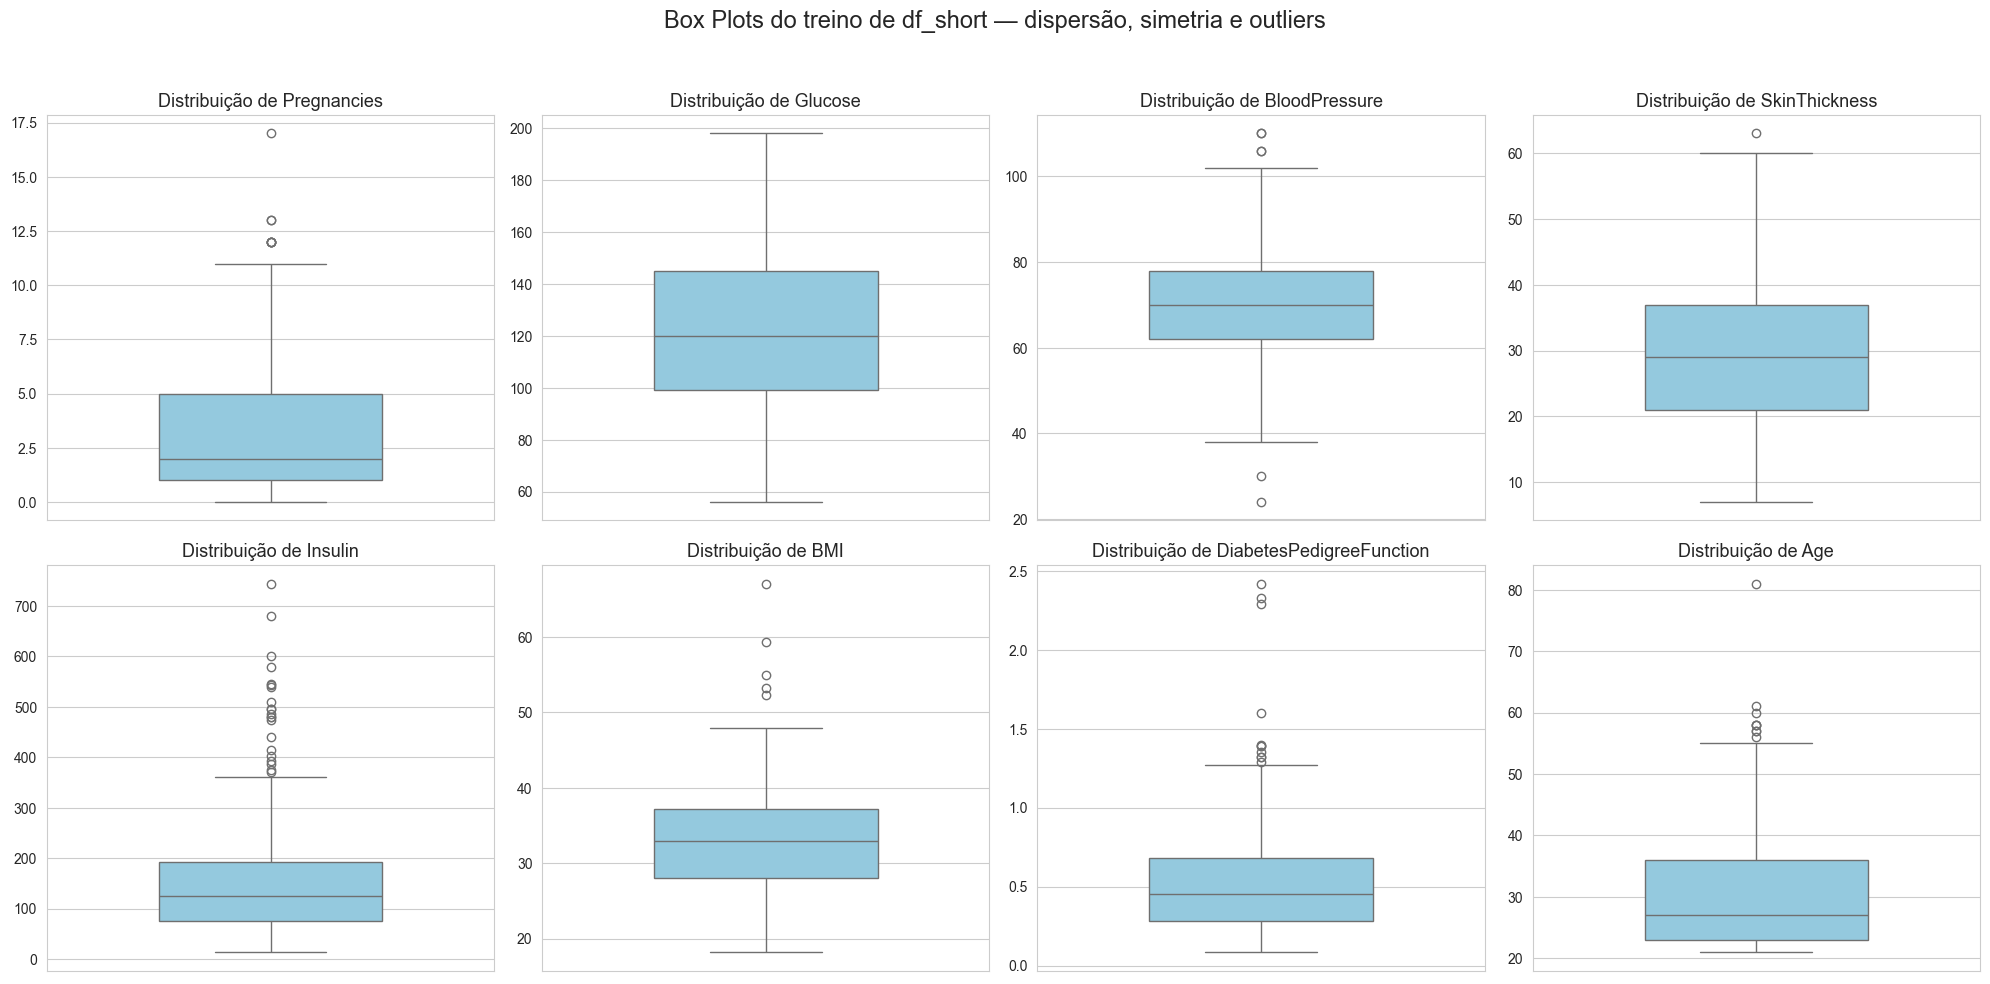

In [12]:
# --- BOX PLOTS do df_short (agora com as 8 preditoras) ---
numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

sns.set_style("whitegrid")
plt.figure(figsize=(20, 10))
plt.suptitle("Box Plots do treino de df_short — dispersão, simetria e outliers", fontsize=17, y=0.98)

for i_col, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i_col + 1)
    sns.boxplot(y=X_train_short[col], color='skyblue', width=0.5)
    plt.title(f'Distribuição de {col}', fontsize=13)
    plt.ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Leitura dos box plots — `df_short`

Com as oito variáveis à vista, dois padrões se destacam:

* **`Insulin` é de longe a mais assimétrica.** A caixa é estreita e comprimida na parte inferior, com uma cauda muito longa para cima — o limite superior do IQR chega a 367,5 mu U/ml. Isso é fisiologicamente esperado: na resistência à insulina, o pâncreas compensa produzindo quantidades muito acima do normal.
* **`SkinThickness` e `BMI`** têm perfis parecidos entre si, coerentes com a correlação de 0,66 entre elas — ambas medem, indiretamente, a mesma coisa.

**Um alerta importante sobre `Age`:** neste conjunto o limite superior do IQR fica em **55,5 anos**. Como o `df_short` tem apenas 392 pacientes e a maioria é jovem, toda paciente acima de 55 anos é tratada como outlier e sai do **treino**.

Isso tem uma consequência que convém registrar com honestidade: mesmo filtrando apenas o treino, a distribuição de aprendizado fica enviesada. A proporção de diabéticas no treino do `df_short` cai de **33,2% para 27,5%** após a remoção — ou seja, o critério do IQR remove desproporcionalmente as pacientes doentes, que são justamente as de valores extremos.

O conjunto de teste permanece intacto, então a **avaliação continua honesta**. Mas o modelo aprende a partir de uma população um pouco mais jovem e mais saudável do que a real. É uma limitação do critério do IQR aplicado a dados clínicos, e um argumento a favor de, em uma próxima iteração, **manter os outliers** e deixar que modelos robustos a eles (as árvores) lidem com o problema.

#### Removendo outliers do `df_short` — também apenas no treino

Mesmo procedimento, agora sobre as oito variáveis preditoras do `df_short`.

In [13]:
# --- LIMITES DE OUTLIER APRENDIDOS SOMENTE COM O TREINO ---
colunas_para_verificar = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                          'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

print("--- Limites calculados a partir do conjunto de treino (critério IQR) ---")
limites = {}
for coluna in colunas_para_verificar:
    Q1 = X_train_short[coluna].quantile(0.25)
    Q3 = X_train_short[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limites[coluna] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    print(f"Coluna '{coluna}': [{limites[coluna][0]:.2f}, {limites[coluna][1]:.2f}]")

# --- APLICAR O FILTRO APENAS AO TREINO ---
X_train_short_outlier = X_train_short.copy()
y_train_short_outlier = y_train_short.copy()

for coluna in colunas_para_verificar:
    inf, sup = limites[coluna]
    mascara = (X_train_short_outlier[coluna] >= inf) & (X_train_short_outlier[coluna] <= sup)
    X_train_short_outlier = X_train_short_outlier[mascara]
    y_train_short_outlier = y_train_short_outlier[mascara]

print("\n--- Resultado ---")
print(f"Treino: {len(X_train_short)} -> {len(X_train_short_outlier)} "
      f"(removidos {len(X_train_short) - len(X_train_short_outlier)} outliers)")
print(f"Teste:  {len(X_test_short)} -> {len(X_test_short)} (INTACTO, de propósito)")
print(f"Proporção de diabéticas no treino após a limpeza: {y_train_short_outlier.mean():.1%}")

print("\n--- Amostra do treino limpo ---")
display(X_train_short_outlier.head())

--- Limites calculados a partir do conjunto de treino (critério IQR) ---
Coluna 'Pregnancies': [-5.00, 11.00]
Coluna 'Glucose': [30.00, 214.00]
Coluna 'BloodPressure': [38.00, 102.00]
Coluna 'SkinThickness': [-3.00, 61.00]
Coluna 'Insulin': [-100.50, 367.50]
Coluna 'BMI': [14.20, 51.00]
Coluna 'DiabetesPedigreeFunction': [-0.31, 1.27]
Coluna 'Age': [3.50, 55.50]

--- Resultado ---
Treino: 313 -> 262 (removidos 51 outliers)
Teste:  79 -> 79 (INTACTO, de propósito)
Proporção de diabéticas no treino após a limpeza: 27.5%

--- Amostra do treino limpo ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
503,7,94.0,64.0,25.0,79.0,33.3,0.738,41
329,6,105.0,70.0,32.0,68.0,30.8,0.122,37
646,1,167.0,74.0,17.0,144.0,23.4,0.447,33
382,1,109.0,60.0,8.0,182.0,25.4,0.947,21
561,0,198.0,66.0,32.0,274.0,41.3,0.502,28


### Normalização ou padronização?

Antes de treinar, é preciso decidir como colocar as variáveis em uma escala comum. Esta subseção é **conceitual**: na prática, a padronização é aplicada dentro do `Pipeline` de cada modelo, na seção 4.5 — nunca sobre o dataset inteiro, para não vazar informação do teste.

#### 1. Normalização (Min-Max Scaling)

*   **O que faz?** Transforma os dados para um intervalo fixo, geralmente entre **0 e 1**.
*   **Fórmula:** `X_norm = (X - X_min) / (X_max - X_min)`
*   **Prós:** garante que todos os dados fiquem exatamente na mesma faixa. Útil para redes neurais e para visualização.
*   **Contras:** é **extremamente sensível a outliers**. Um único valor muito alto comprime todos os demais em uma faixa estreita, distorcendo as distâncias relativas.

#### 2. Padronização (*Standardization* / Z-score)

*   **O que faz?** Transforma os dados para média **0** e desvio-padrão **1**, sem limitá-los a um intervalo.
*   **Fórmula:** `X_std = (X - μ) / σ`
*   **Prós:** bem menos sensível a outliers, preserva a forma da distribuição original e é pré-requisito de vários algoritmos que assumem dados centrados em zero.
*   **Contras:** não coloca os dados em intervalo fixo — raramente um problema em classificação clássica.

#### Por que escolhemos a padronização

1.  **Regressão Logística e SVM** convergem mais rápido e produzem coeficientes comparáveis entre si quando os dados estão centrados em zero e com a mesma variância.
2.  **KNN** depende de distâncias: sem padronizar, `Glucose` (dezenas a centenas) dominaria completamente `DiabetesPedigreeFunction` (valores entre 0 e 2).
3.  **Random Forest e XGBoost** não precisam de padronização — árvores dividem uma variável por vez e são invariantes à escala. Aplicá-la não prejudica o desempenho e permite usar exatamente o mesmo `Pipeline` para todos os modelos, tornando a comparação justa.
4.  Como os outliers foram tratados apenas no treino, e ainda assim de forma parcial, a robustez da padronização a valores extremos é uma vantagem concreta aqui.

#### Regra de ouro contra o *data leakage*

1.  **Ajustar (`fit`) o scaler APENAS no conjunto de treino** — a média e o desvio-padrão devem vir exclusivamente de `X_train`.
2.  **Transformar (`transform`) os dois conjuntos** com o scaler já ajustado.

É exatamente isso que o `Pipeline` faz automaticamente a cada `fit`, inclusive dentro de cada partição da validação cruzada. Fazer essa conta manualmente sobre o dataset completo, antes da divisão, é o erro que mais infla resultados sem que ninguém perceba.

## 4.5 Treinamento dos modelos

Cinco algoritmos são treinados nos dois datasets, sempre dentro de um `Pipeline` com `StandardScaler`. As justificativas de cada escolha estão na seção 2.2.

### df_limpo

In [14]:
# --- DEFINIÇÃO DOS PIPELINES ---
# Cada pipeline recebe um StandardScaler() NOVO: a padronização é aprendida dentro
# do próprio pipeline, a cada fit, usando apenas os dados de treino daquele momento.
# É isso que impede vazamento de dados, inclusive dentro da validação cruzada.
# probability=True no SVC é necessário para obter probabilidades e calcular a AUC.
def montar_modelos():
    return {
        'Regressão Logística': Pipeline([('scaler', StandardScaler()),
                                         ('model', LogisticRegression(random_state=35, max_iter=2000))]),
        'KNN (k-NN)':          Pipeline([('scaler', StandardScaler()),
                                         ('model', KNeighborsClassifier())]),
        'Random Forest':       Pipeline([('scaler', StandardScaler()),
                                         ('model', RandomForestClassifier(random_state=35))]),
        'XGBoost':             Pipeline([('scaler', StandardScaler()),
                                         ('model', XGBClassifier(random_state=35, eval_metric='logloss'))]),
        'SVM':                 Pipeline([('scaler', StandardScaler()),
                                         ('model', SVC(random_state=35, probability=True))]),
    }


def treinar_e_avaliar(modelos, X_tr, y_tr, X_te, y_te, titulo):
    """Treina cada modelo e devolve a tabela de métricas ordenada por RECALL."""
    linhas = []
    for nome, pipe in modelos.items():
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)
        linhas.append({
            'Modelo': nome,
            'Acurácia': accuracy_score(y_te, y_pred),
            'Precisão': precision_score(y_te, y_pred, zero_division=0),
            'Recall': recall_score(y_te, y_pred),
            'F1-Score': f1_score(y_te, y_pred),
            'AUC': roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1]),
        })
    tabela = pd.DataFrame(linhas).sort_values('Recall', ascending=False).round(3)
    print(f"\n--- {titulo} ---")
    print(f"(avaliado em {len(y_te)} pacientes, das quais {int(y_te.sum())} diabéticas)")
    display(tabela.reset_index(drop=True))
    return tabela


# Treino com df_limpo: outliers removidos do treino, teste intacto
modelos_limpo = montar_modelos()
results_df_limpo = treinar_e_avaliar(
    modelos_limpo, X_train_limpo_outlier, y_train_limpo_outlier,
    X_test_limpo, y_test_limpo, "Resultados do df_limpo")


--- Resultados do df_limpo ---
(avaliado em 145 pacientes, das quais 50 diabéticas)


,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC
0,Regressão Logística,0.779,0.680,0.68,0.680,0.867
1,XGBoost,0.738,0.615,0.64,0.627,0.791
2,Random Forest,0.772,0.689,0.62,0.653,0.832
3,KNN (k-NN),0.731,0.628,0.54,0.581,0.803
4,SVM,0.759,0.714,0.50,0.588,0.830


### df_short

In [15]:
# Treino com df_short: mesmo procedimento
modelos_short = montar_modelos()
results_df_short = treinar_e_avaliar(
    modelos_short, X_train_short_outlier, y_train_short_outlier,
    X_test_short, y_test_short, "Resultados do df_short")


--- Resultados do df_short ---
(avaliado em 79 pacientes, das quais 26 diabéticas)


,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC
0,Random Forest,0.797,0.778,0.538,0.636,0.862
1,Regressão Logística,0.772,0.786,0.423,0.550,0.856
2,XGBoost,0.734,0.647,0.423,0.512,0.856
3,KNN (k-NN),0.722,0.625,0.385,0.476,0.736
4,SVM,0.684,0.571,0.154,0.242,0.790


## 4.6 Avaliação dos modelos

### Por que o recall é a métrica prioritária

As tabelas acima estão ordenadas por **recall**, e não por acurácia, porque os dois tipos de erro têm custos muito diferentes neste problema:

* **Falso positivo** — uma paciente saudável é sinalizada como de risco. Custo: uma consulta e exames adicionais desnecessários.
* **Falso negativo** — uma paciente diabética é classificada como saudável. Custo: ela não é chamada para acompanhamento e a doença progride sem tratamento.

Em uma ferramenta de **triagem**, como a descrita no cenário da clínica, o segundo erro é incomparavelmente mais grave. O recall mede exatamente a fração de diabéticas que o modelo consegue encontrar.

A **AUC** complementa: ela avalia a qualidade do *ordenamento de risco* produzido pelo modelo em todos os limiares de decisão, e não apenas no corte padrão de 0,5.

### Validação cruzada

Os conjuntos de teste são pequenos — poucas dezenas de pacientes. Uma diferença de alguns pontos percentuais entre modelos pode significar **uma única paciente**.

A validação cruzada estratificada em 5 *folds* treina e avalia cada modelo cinco vezes, em partições diferentes de todo o dataset, e reporta média e desvio-padrão. Uma diferença só deve ser considerada real se for maior que o desvio.

In [16]:
# --- VALIDAÇÃO CRUZADA ESTRATIFICADA (5 folds) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=35)

for nome_base, base in [('df_limpo', df_limpo), ('df_short', df_short)]:
    X_completo = base.drop(['Outcome'], axis=1)
    y_completo = base['Outcome']
    print(f"\n--- {nome_base} ({len(base)} pacientes) ---")
    print(f"{'Modelo':<22} {'Recall':>16} {'Acurácia':>16}")
    for nome, pipe in montar_modelos().items():
        r = cross_val_score(pipe, X_completo, y_completo, cv=cv, scoring='recall')
        a = cross_val_score(pipe, X_completo, y_completo, cv=cv, scoring='accuracy')
        print(f"{nome:<22} {r.mean():>7.3f} (+/-{r.std():.3f}) {a.mean():>7.3f} (+/-{a.std():.3f})")


--- df_limpo (724 pacientes) ---
Modelo                           Recall         Acurácia
Regressão Logística      0.575 (+/-0.071)   0.774 (+/-0.035)


KNN (k-NN)               0.582 (+/-0.093)   0.749 (+/-0.040)


Random Forest            0.602 (+/-0.083)   0.772 (+/-0.042)


XGBoost                  0.598 (+/-0.102)   0.742 (+/-0.030)


SVM                      0.558 (+/-0.061)   0.767 (+/-0.029)

--- df_short (392 pacientes) ---
Modelo                           Recall         Acurácia
Regressão Logística      0.562 (+/-0.058)   0.778 (+/-0.037)
KNN (k-NN)               0.531 (+/-0.099)   0.747 (+/-0.038)


Random Forest            0.608 (+/-0.078)   0.793 (+/-0.022)


XGBoost                  0.638 (+/-0.083)   0.783 (+/-0.034)


SVM                      0.569 (+/-0.066)   0.770 (+/-0.016)


### Matriz de confusão e curva ROC

Dois gráficos que mostram o comportamento do modelo além do número único de acurácia.

Melhor modelo por recall — df_limpo: Regressão Logística | df_short: Random Forest
df_limpo — Regressão Logística: 16 falsos negativos de 50 diabéticas no teste
df_short — Random Forest: 12 falsos negativos de 26 diabéticas no teste


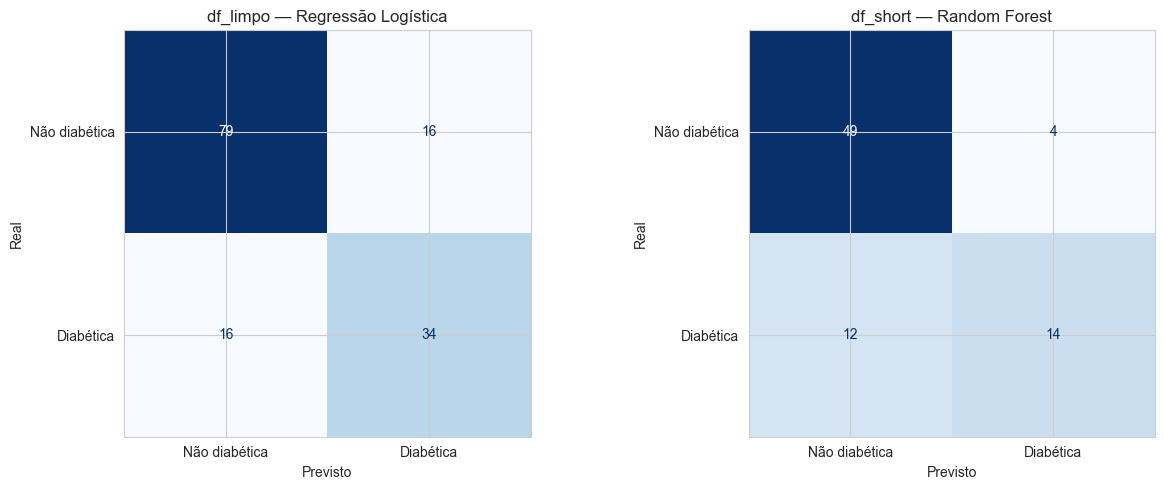

In [17]:
# --- MATRIZ DE CONFUSÃO DO MELHOR MODELO DE CADA DATAFRAME (visualização 4 de 6) ---

# O "melhor" é definido pelo maior recall, coerente com a prioridade do problema
melhor_limpo = results_df_limpo.iloc[0]['Modelo']
melhor_short = results_df_short.iloc[0]['Modelo']
print(f"Melhor modelo por recall — df_limpo: {melhor_limpo} | df_short: {melhor_short}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (titulo, modelo, X_te, y_te) in zip(axes, [
        (f'df_limpo — {melhor_limpo}', modelos_limpo[melhor_limpo], X_test_limpo, y_test_limpo),
        (f'df_short — {melhor_short}', modelos_short[melhor_short], X_test_short, y_test_short)]):
    cm = confusion_matrix(y_te, modelo.predict(X_te))
    ConfusionMatrixDisplay(cm, display_labels=['Não diabética', 'Diabética']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
    # O quadrante inferior-esquerdo é o dos FALSOS NEGATIVOS: o erro mais grave
    print(f"{titulo}: {cm[1, 0]} falsos negativos de {cm[1].sum()} diabéticas no teste")

plt.tight_layout()
plt.show()

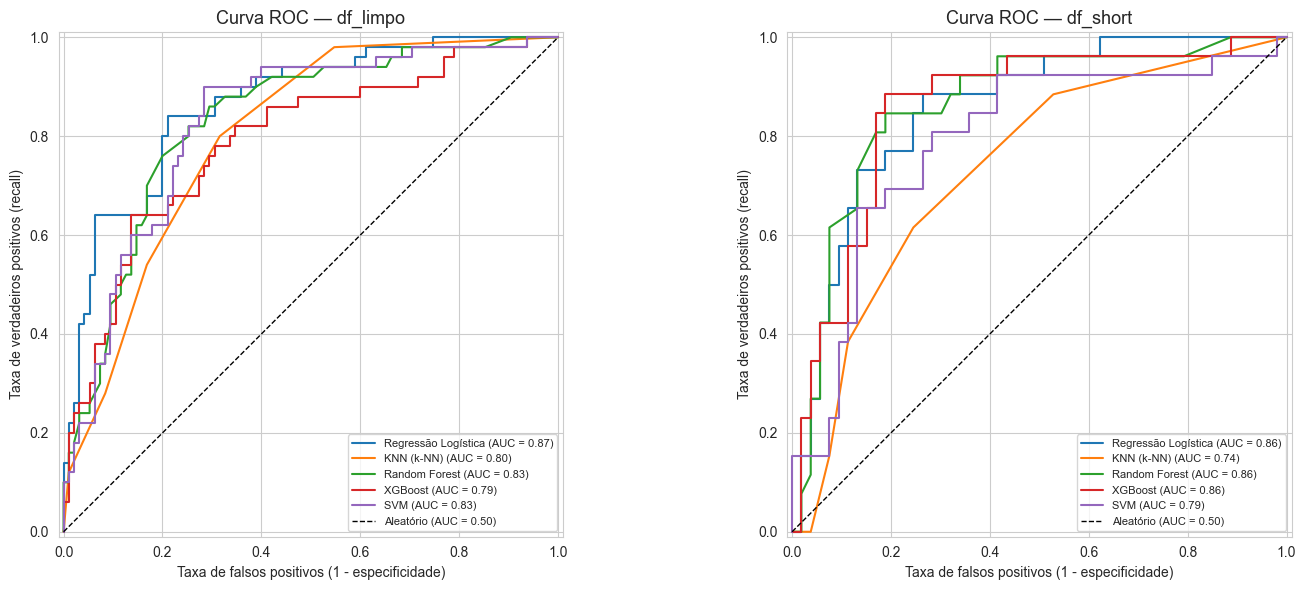

In [18]:
# --- CURVA ROC (visualização 5 de 6) ---
# Mostra o trade-off entre sensibilidade e falsos positivos em TODOS os limiares,
# e não apenas no corte padrão de 0,5 usado pelo predict().

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (nome_base, modelos, X_te, y_te) in zip(axes, [
        ('df_limpo', modelos_limpo, X_test_limpo, y_test_limpo),
        ('df_short', modelos_short, X_test_short, y_test_short)]):
    for nome, pipe in modelos.items():
        RocCurveDisplay.from_estimator(pipe, X_te, y_te, name=nome, ax=ax)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC = 0.50)')
    ax.set_title(f'Curva ROC — {nome_base}', fontsize=13)
    ax.set_xlabel('Taxa de falsos positivos (1 - especificidade)')
    ax.set_ylabel('Taxa de verdadeiros positivos (recall)')
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## 4.7 Predição e interpretabilidade do modelo

Um modelo de apoio à decisão clínica que não consegue explicar **por que** classificou uma paciente como de risco não é utilizável na prática: o médico precisa saber em que se apoiar para conversar com a paciente, e a clínica precisa poder auditar a decisão.

Usaremos duas técnicas complementares sobre o `df_short`, que contém todas as oito variáveis:

1. **Coeficientes da Regressão Logística** — interpretabilidade *intrínseca*. Como o modelo é linear, cada coeficiente indica a direção e a intensidade do efeito de cada variável. Convertidos em *odds ratio* (razão de chances), tornam-se diretamente legíveis: "cada desvio-padrão a mais de glicose multiplica a chance de diabetes por X".
2. **Permutation Importance** — interpretabilidade *post-hoc* e agnóstica ao modelo. Embaralha uma variável por vez e mede o quanto o desempenho cai. Se embaralhar não muda nada, a variável não estava sendo usada.

In [19]:
# --- 1. COEFICIENTES DA REGRESSÃO LOGÍSTICA (interpretabilidade intrínseca) ---

modelo_lr = modelos_short['Regressão Logística']
nomes_features = X_train_short.columns

# Como os dados foram padronizados dentro do pipeline, os coeficientes são
# COMPARÁVEIS entre si: todos estão na mesma escala (desvios-padrão).
coefs = modelo_lr.named_steps['model'].coef_[0]

interpretacao = pd.DataFrame({
    'Variável': nomes_features,
    'Coeficiente': coefs,
    # exp(coef) = odds ratio: quanto a chance é multiplicada a cada desvio-padrão a mais
    'Odds Ratio': np.exp(coefs)
}).sort_values('Coeficiente', key=abs, ascending=False).round(3)

print("Coeficientes da Regressão Logística (dados padronizados):\n")
display(interpretacao.reset_index(drop=True))

print("\nComo ler: Odds Ratio > 1 aumenta a chance de diabetes; < 1 diminui.")
print("Exemplo: um OR de 2,0 significa que a chance DOBRA a cada desvio-padrão")
print("a mais naquela variável, mantidas as demais constantes.")

Coeficientes da Regressão Logística (dados padronizados):



,Variável,Coeficiente,Odds Ratio
0,Glucose,1.127,3.085
1,Age,0.590,1.804
2,DiabetesPedigreeFunction,0.353,1.424
3,BMI,0.260,1.297
4,Pregnancies,-0.134,0.874
5,Insulin,0.120,1.128
6,SkinThickness,0.091,1.095
7,BloodPressure,-0.038,0.963



Como ler: Odds Ratio > 1 aumenta a chance de diabetes; < 1 diminui.
Exemplo: um OR de 2,0 significa que a chance DOBRA a cada desvio-padrão
a mais naquela variável, mantidas as demais constantes.


#### Leitura dos coeficientes

| Variável | Odds Ratio | Interpretação |
| :--- | ---: | :--- |
| **`Glucose`** | **3,09** | Dominante. A cada desvio-padrão a mais de glicose, a chance de diabetes **triplica**. Nenhuma outra variável chega perto. |
| **`Age`** | 1,80 | Segundo fator mais forte: a chance quase dobra a cada desvio-padrão de idade. |
| `DiabetesPedigreeFunction` | 1,42 | A predisposição genética tem efeito moderado e consistente. |
| `BMI` | 1,30 | Efeito moderado, menor do que a literatura clínica sugeriria — provavelmente porque parte de sua informação já está contida em `Glucose` e `SkinThickness`. |
| `Insulin` | 1,13 | **Efeito pequeno.** |
| `SkinThickness` | 1,10 | **Efeito pequeno.** |
| `Pregnancies` | 0,87 | Coeficiente **negativo**, o que parece contraintuitivo. Explicação: `Pregnancies` e `Age` têm correlação de 0,68; com a idade já no modelo, o número de gestações deixa de agregar informação e o coeficiente se torna instável. É um efeito de multicolinearidade, não um achado clínico. |
| `BloodPressure` | 0,96 | Praticamente nulo, coerente com a baixa correlação e com a sobreposição vista no histograma. |

**Este é o resultado mais importante do projeto.** As duas variáveis pelas quais o `df_short` sacrificou metade do dataset — `Insulin` e `SkinThickness` — ficaram entre as **três de menor efeito** no modelo. A informação que elas carregam já está, em grande parte, contida em `Glucose` e `BMI`, exatamente como a análise de multicolinearidade havia sugerido.

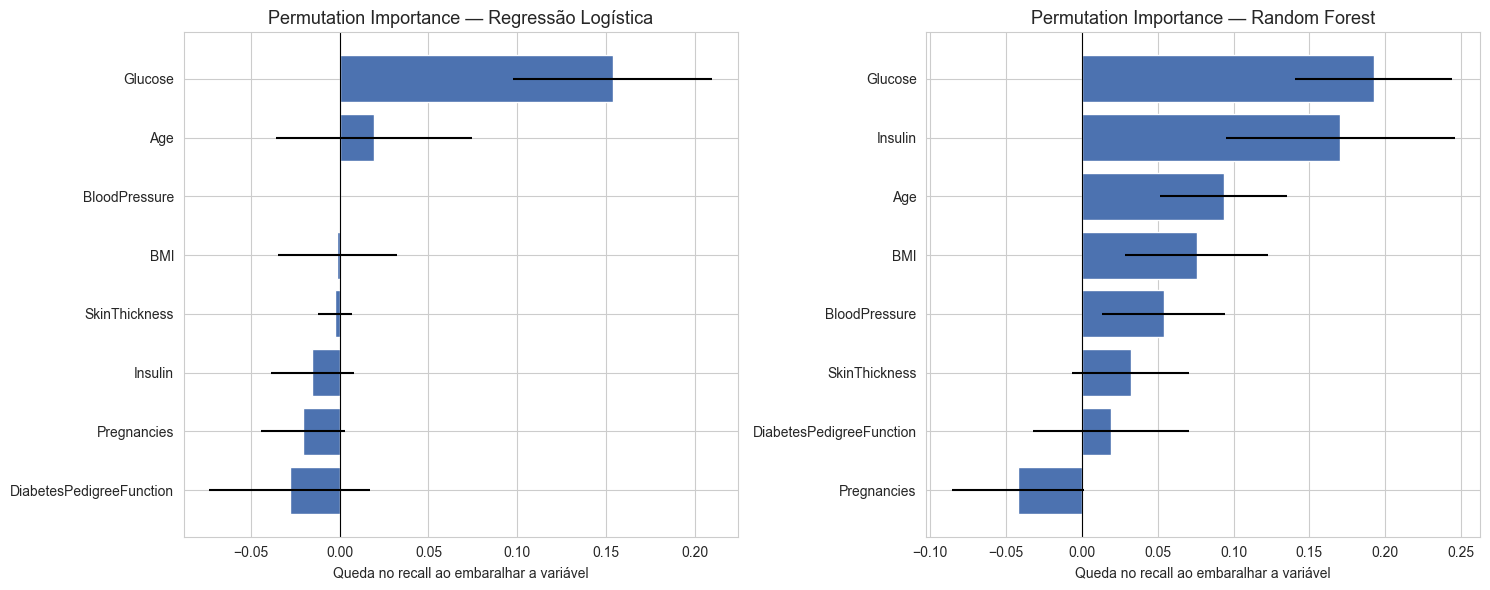

In [20]:
# --- 2. PERMUTATION IMPORTANCE (visualização 6 de 6) ---
# Interpretabilidade agnóstica ao modelo.
# Embaralha uma variável por vez no conjunto de TESTE e mede quanto o recall cai.
# n_repeats=30 repete o embaralhamento para estimar também a incerteza.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (nome_modelo, modelo) in zip(axes, [
        ('Regressão Logística', modelos_short['Regressão Logística']),
        ('Random Forest', modelos_short['Random Forest'])]):

    imp = permutation_importance(modelo, X_test_short, y_test_short,
                                 n_repeats=30, random_state=35, scoring='recall')

    ordem = imp.importances_mean.argsort()
    ax.barh(np.array(nomes_features)[ordem], imp.importances_mean[ordem],
            xerr=imp.importances_std[ordem], color='#4C72B0')
    ax.set_title(f'Permutation Importance — {nome_modelo}', fontsize=13)
    ax.set_xlabel('Queda no recall ao embaralhar a variável')
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

#### Leitura da *permutation importance*

O gráfico mede quanto o **recall cai** quando cada variável é embaralhada no conjunto de teste. Quanto maior a barra, mais o modelo dependia daquela variável.

Os dois modelos concordam no essencial: **`Glucose` é a variável de que ambos mais dependem**, com folga. Variáveis cuja barra fica próxima de zero (ou negativa, o que é ruído da própria aleatorização) não estavam sendo efetivamente usadas — embaralhá-las não muda o resultado.

Vale notar que as duas técnicas chegam à mesma conclusão por caminhos diferentes: os coeficientes olham a *estrutura* do modelo linear, a *permutation importance* olha o *comportamento* dele diante de dados perturbados. Quando concordam, a leitura é confiável.

In [21]:
# --- 3. PREDIÇÃO PARA UMA PACIENTE NOVA ---
# Demonstra o uso prático: o modelo devolve uma PROBABILIDADE, que é o "score de
# risco" descrito no cenário da clínica — mais útil que o rótulo sim/não.

paciente_exemplo = pd.DataFrame([{
    'Pregnancies': 3,
    'Glucose': 168.0,
    'BloodPressure': 74.0,
    'SkinThickness': 33.0,
    'Insulin': 180.0,
    'BMI': 34.5,
    'DiabetesPedigreeFunction': 0.62,
    'Age': 47
}])[X_train_short.columns]   # garante a mesma ordem de colunas do treino

prob = modelo_lr.predict_proba(paciente_exemplo)[0, 1]
classe = modelo_lr.predict(paciente_exemplo)[0]

print("--- Ficha da paciente ---")
display(paciente_exemplo)
print(f"\nProbabilidade estimada de diabetes: {prob:.1%}")
print(f"Classificação no limiar padrão (0,5): {'DIABÉTICA' if classe == 1 else 'não diabética'}")

# Contribuição de cada variável para esta paciente específica:
# valor padronizado x coeficiente = quanto aquela variável empurrou a decisão
valores_padronizados = modelo_lr.named_steps['scaler'].transform(paciente_exemplo)[0]
contribuicoes = pd.DataFrame({
    'Variável': nomes_features,
    'Valor da paciente': paciente_exemplo.iloc[0].values,
    'Contribuição': valores_padronizados * coefs
}).sort_values('Contribuição', ascending=False).round(3)

print("\n--- Por que o modelo decidiu assim (contribuição de cada variável) ---")
display(contribuicoes.reset_index(drop=True))
print("Valores positivos empurraram para 'diabética'; negativos, para 'não diabética'.")

--- Ficha da paciente ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,3,168.0,74.0,33.0,180.0,34.5,0.62,47



Probabilidade estimada de diabetes: 88.4%
Classificação no limiar padrão (0,5): DIABÉTICA

--- Por que o modelo decidiu assim (contribuição de cada variável) ---


,Variável,Valor da paciente,Contribuição
0,Glucose,168.00,1.817
1,Age,47.00,1.209
2,DiabetesPedigreeFunction,0.62,0.200
3,BMI,34.50,0.092
4,Insulin,180.00,0.083
5,SkinThickness,33.00,0.043
6,Pregnancies,3.00,-0.010
7,BloodPressure,74.00,-0.014


Valores positivos empurraram para 'diabética'; negativos, para 'não diabética'.


# 5. Conclusões

## Como o projeto funciona, em resumo

O notebook percorre o caminho completo de um projeto de IA em saúde:

1. **Abertura** do dataset Pima Indians Diabetes (768 pacientes, 8 variáveis clínicas).
2. **Pré-processamento:** identificação de que zeros em `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` e `BMI` são valores ausentes disfarçados, e sua conversão em `NaN`.
3. **Dois datasets alternativos**, para responder experimentalmente à pergunta central: *vale mais ter mais pacientes ou mais exames por paciente?*
4. **AED** com quatro tipos de visualização: mapa de calor de correlação, histogramas por classe, box plots e matriz de confusão, além da curva ROC.
5. **Treinamento** de cinco algoritmos em cada dataset, sempre dentro de um `Pipeline` com padronização.
6. **Avaliação** por acurácia, precisão, recall, F1 e AUC, mais validação cruzada estratificada.
7. **Interpretabilidade** por coeficientes e *permutation importance*, além de uma predição individual explicada.

---

## Principais achados

### 1. `Glucose` domina, e o resto é complemento

Em todas as análises — correlação, histogramas, coeficientes e *permutation importance* — a glicose aparece isolada em primeiro lugar. Seu *odds ratio* de **3,09** significa que a chance de diabetes triplica a cada desvio-padrão a mais. Nenhuma outra variável chega perto: a segunda, `Age`, fica em 1,80.

Isso é coerente com a prática clínica, já que o teste de tolerância à glicose é o próprio exame diagnóstico da doença.

### 2. `Insulin` e `SkinThickness` **não** compensaram o custo

Esta é a resposta à pergunta central do projeto, e ela contraria a expectativa inicial.

O `df_short` sacrificou **376 dos 768 pacientes** (49% do dataset) para manter essas duas colunas. A etapa de interpretabilidade mostra que elas têm *odds ratio* de apenas **1,13** e **1,10** — entre as três variáveis de menor efeito de todo o modelo.

A explicação está na multicolinearidade identificada na AED: `Insulin` é fortemente correlacionada com `Glucose`, e `SkinThickness` com `BMI`. Elas carregam, em boa medida, informação que o modelo já possuía.

### 3. Os dois datasets empatam, com leve vantagem para os modelos de árvore no `df_short`

No split único de teste, o `df_limpo` levou vantagem no recall (Regressão Logística com **0,680**, contra **0,538** do melhor modelo no `df_short`). Mas o teste do `df_short` tem apenas 79 pacientes, 26 delas diabéticas — uma paciente vale quase 4 pontos de recall.

A validação cruzada dá o quadro mais confiável:

| Modelo | Recall — `df_limpo` | Recall — `df_short` |
| :--- | :--- | :--- |
| XGBoost | 0,598 ± 0,102 | **0,638 ± 0,083** |
| Random Forest | 0,602 ± 0,083 | 0,608 ± 0,078 |
| SVM | 0,558 ± 0,061 | 0,569 ± 0,066 |
| Regressão Logística | 0,575 ± 0,071 | 0,562 ± 0,058 |
| KNN | 0,582 ± 0,093 | 0,531 ± 0,099 |

**As diferenças são menores que os desvios-padrão.** Não há vencedor estatisticamente distinguível — nem entre modelos, nem entre datasets. O que se pode dizer é que os modelos de árvore (XGBoost e Random Forest) se saem um pouco melhor no `df_short`, e que a Regressão Logística prefere o `df_limpo`, com o dobro de amostras.

### 4. A hipótese inicial não se confirmou

Na seção 2.2 registramos a expectativa de que **os modelos de ensemble superariam os simples**, já que costumam liderar em dados tabulares. Os resultados não sustentam isso:

* No `df_limpo`, a **Regressão Logística** teve o melhor recall no teste (0,680) e o XGBoost ficou em segundo, com o pior desempenho geral entre os cinco em validação cruzada de acurácia (0,742).
* Na validação cruzada, a diferença entre o melhor e o pior modelo é da ordem de 0,08 no recall — menor ou igual aos próprios desvios-padrão.

A explicação mais provável é o **tamanho da amostra**. Modelos de ensemble ganham quando há dados suficientes para que capturem interações complexas entre variáveis. Com 392 a 724 pacientes e 8 variáveis, não há complexidade a capturar que compense a variância adicional que eles introduzem — e a fronteira de decisão do problema, dominada por `Glucose`, é razoavelmente próxima de linear, o que favorece justamente o modelo mais simples.

É um resultado útil de registrar: a escolha do algoritmo importou muito menos do que a qualidade dos dados e o tratamento dado a eles.

### 5. Recomendação prática

Diante do empate técnico, a escolha deve considerar critérios além da métrica:

* **`df_limpo` com Regressão Logística** é a recomendação para a clínica. Usa 724 pacientes em vez de 392, dispensa dois exames caros (`Insulin` e `SkinThickness`) que quase não agregam, e é o modelo mais interpretável — o médico consegue ver o peso de cada fator.
* **`df_short` com XGBoost** só se justificaria se os exames já estivessem disponíveis de rotina e o ganho marginal de recall fosse confirmado com mais dados.

---

## Limitação clínica importante

Mesmo o melhor modelo deixa passar uma fração inaceitável de pacientes doentes:

* `df_limpo` / Regressão Logística: **16 falsos negativos entre 50 diabéticas** no teste (32% não identificadas);
* `df_short` / Random Forest: **12 falsos negativos entre 26** (46% não identificadas).

Para uma ferramenta de triagem isso é insuficiente. A boa notícia está na **AUC de 0,86**: o modelo *ordena* bem o risco, ele apenas está cortando no lugar errado. O limiar padrão de 0,5 usado pelo `predict()` foi feito para problemas simétricos, o que não é o caso aqui.

**Baixar o limiar** — por exemplo para 0,3 — aumentaria o recall substancialmente ao custo de mais falsos positivos. Em uma triagem cujo desfecho é "chamar a paciente para uma consulta de acompanhamento", esse é um custo aceitável. A curva ROC é exatamente o instrumento para escolher esse ponto de operação com o corpo clínico.

---

## Próximos passos

1. **Ajustar o limiar de decisão** com base na curva ROC, em vez de aceitar o 0,5 padrão. É a mudança de maior impacto e menor custo.
2. **Imputação preditiva** (KNN ou regressão) dentro de um `Pipeline` para `Insulin` e `SkinThickness`, permitindo usar os 768 pacientes sem descartar colunas — a Opção C que foi deixada de fora por complexidade.
3. **Otimização de hiperparâmetros** com `GridSearchCV`, usando recall como métrica-alvo. Todos os modelos rodaram com parâmetros padrão.
4. **Balanceamento de classes**, via `class_weight='balanced'` ou SMOTE, já que apenas um terço das pacientes é diabética.
5. **Validação externa** em uma população diferente. O dataset é composto exclusivamente por mulheres Pima com 21 anos ou mais — o modelo não deve ser aplicado a outros perfis sem revalidação. Esta é, também, uma limitação ética: um modelo treinado em uma população específica pode ter desempenho pior justamente nos grupos sub-representados.